# Analyse Exploratoire des Données (EDA) — Foodiz

**Objectif** : Explorer le dataset Open Food Facts pour comprendre la structure, la qualité et les distributions des données nutritionnelles, en vue de construire un système de recommandation de produits alimentaires adapté aux régimes des utilisateurs.

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_seq_items', None)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des données

On fait déjà un filtre au niveau des colonnes car sinon le temps de chargement du fichier pennait trop de temps. Dans une précédente analise (qu'on a supprimé), on a remarqué que la plupart des colonnes correspondent à des macro-nutiment qui ne sont pas toujours, pour ne pas dire "presque jamais", remplis. Ce sont des macro-nutriment secondaire que nous ne voulons pas inclure dans notre analise. Ils ne sont pas responsable d'allergie ou d'autre problème de santé nous considérons qu'ils ne sont pas important. 

In [2]:
cols_identite = ['code', 'product_name', 'brands', 'categories', 'categories_en', 'main_category_en']
cols_qualite = ['nutriscore_score', 'nutriscore_grade', 'nova_group']
cols_nutrition = [
    'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'carbohydrates_100g', 'sugars_100g', 'fiber_100g',
    'proteins_100g', 'salt_100g', 'sodium_100g'
]
cols_regime = [
    'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags',
    'allergens', 'allergens_en', 'traces', 'traces_en',
    'labels', 'labels_tags', 'labels_en',
    'additives_n', 'additives_tags'
]
cols_meta = ['countries_en', 'image_url', 'completeness']

cols_utiles = cols_identite + cols_qualite + cols_nutrition + cols_regime + cols_meta

df = pd.read_csv(
    "../Data/openfoodfacts-products.csv",
    sep="\t",
    usecols=cols_utiles,
    engine="pyarrow",
    on_bad_lines="skip"
)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes (sur 211 au total)")
print(f"Taille en memoire : {df.memory_usage(deep=True).sum() / 1e9:.2f} Go")
df.head(3)
# Temps : 1m 31s

Dataset : 4,535,040 lignes x 33 colonnes (sur 211 au total)
Taille en memoire : 5.64 Go


,code,product_name,brands,categories,categories_en,main_category_en,nutriscore_score,nutriscore_grade,nova_group,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_en,labels,labels_tags,labels_en,additives_n,additives_tags,countries_en,image_url,completeness
0,54.0,Limonade artisanale a la rose,None,None,None,None,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,None,None,None,None,None,NaN,None,France,https://images.openfoodfacts.org/images/produc...,0.1625
1,63.0,M&amp;M white,Fitpiggy,None,None,None,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...","en:weizenmehl,en:rapsol,en:speisesalz,en:meers...","en:palm-oil-content-unknown,en:vegan-status-un...",None,NaN,None,None,None,None,None,0.0,None,France,https://images.openfoodfacts.org/images/produc...,0.6625
2,114.0,Chocolate n3,Jeff de Bruges,None,None,None,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,None,None,"Green Dot,Made in France","en:green-dot,en:made-in-france","Green Dot,Made in France",NaN,None,France,https://images.openfoodfacts.org/images/produc...,0.4750


## 3. Vue d'ensemble du dataset

In [3]:
df.dtypes.value_counts()

object     18
float64    15
Name: count, dtype: int64

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code,4535040.0,NaN,NaN,NaN,1226530242001465498183626619487545778683372254...,2611973833275349113966341361092617176020875861...,2.0,787359134389.0,3770008970041.5,7501040070673.75,5562363708686324783317343908886711114129007466...
product_name,4198935,2634425,Miel,2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brands,2852185,483014,Carrefour,27208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories,1859206,330181,undefined,34569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories_en,1860169,198109,Snacks,35486,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_category_en,1860169,80172,Groceries,64381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nutriscore_score,1376326.0,NaN,NaN,NaN,10.959251,10.293075,-17.0,2.0,11.0,19.0,55.0
nutriscore_grade,4490851,7,unknown,3013799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nova_group,1135254.0,NaN,NaN,NaN,3.342236,1.0272,1.0,3.0,4.0,4.0,4.0
energy-kcal_100g,2236278.0,NaN,NaN,NaN,6364457819.751156,9517530676758.570312,-113.86,109.0,253.0,394.0,14232696253056154.0


## 4. Analyse des valeurs manquantes

Comprendre quelles colonnes sont exploitables et lesquelles sont trop creuses pour notre cas d'usage.

In [5]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing_df = missing.reset_index()
missing_df.columns = ['colonne', 'pct_manquant']

print(f"Colonnes avec > 90% de valeurs manquantes : {(missing > 90).sum()}")
print(f"Colonnes avec > 50% de valeurs manquantes : {(missing > 50).sum()}")
print(f"Colonnes avec < 10% de valeurs manquantes : {(missing < 10).sum()}")

missing_df.head(30)

Colonnes avec > 90% de valeurs manquantes : 4
Colonnes avec > 50% de valeurs manquantes : 26
Colonnes avec < 10% de valeurs manquantes : 5


,colonne,pct_manquant
0,allergens_en,100.000000
1,traces,96.192889
2,traces_en,94.928027
3,allergens,91.892376
4,additives_tags,84.547656
5,fiber_100g,77.214865
6,nova_group,74.967057
7,labels_en,72.721497
8,labels,72.721453
9,labels_tags,72.720880


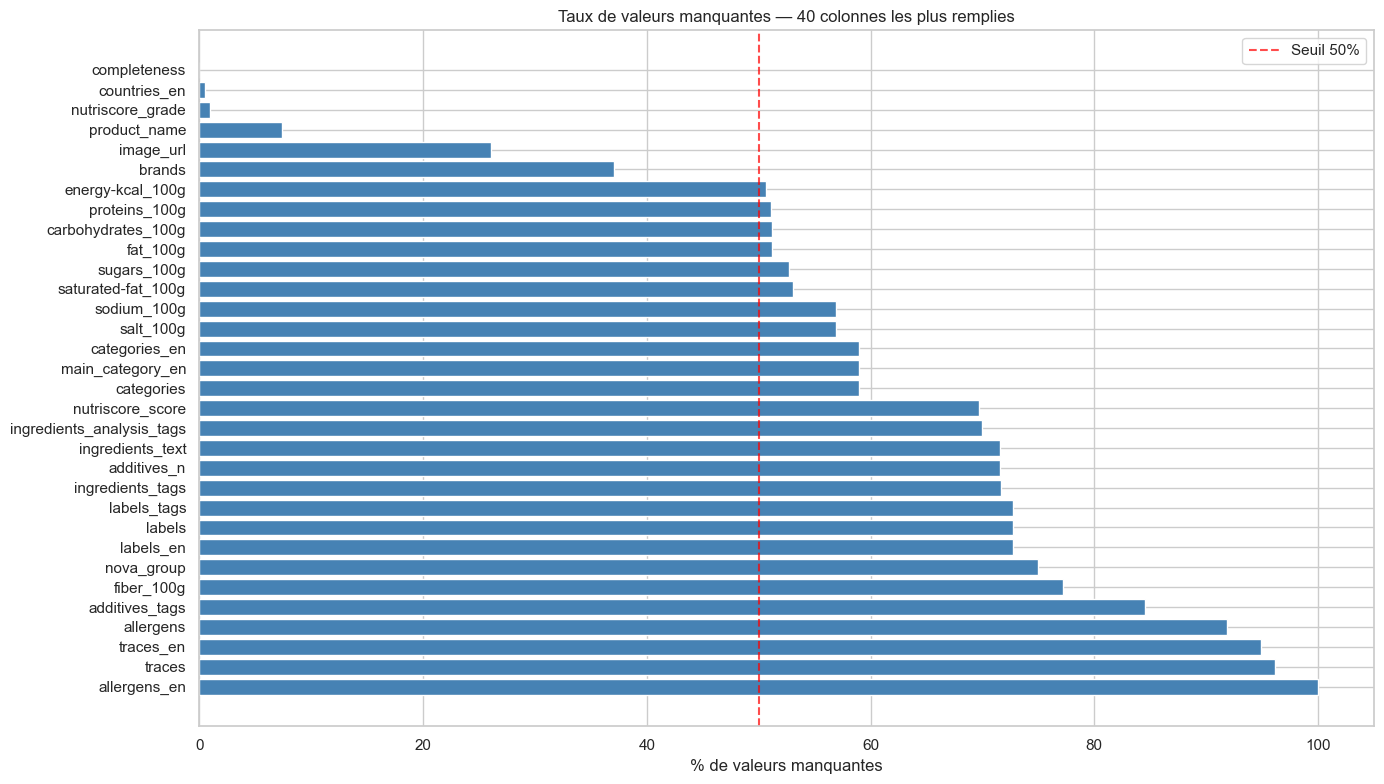

In [6]:
fig, ax = plt.subplots(figsize=(14, 8))
top_missing = missing_df[missing_df['pct_manquant'] > 0].tail(40)
ax.barh(top_missing['colonne'], top_missing['pct_manquant'], color='steelblue')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de valeurs manquantes — 40 colonnes les plus remplies')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Seuil 50%')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Taux de valeurs manquantes des colonnes selectionnees

In [7]:
df_focus = df
df_focus.isnull().mean().sort_values(ascending=False).apply(lambda x: f"{x:.1%}")

allergens_en                 100.0%
traces                        96.2%
traces_en                     94.9%
allergens                     91.9%
additives_tags                84.5%
fiber_100g                    77.2%
nova_group                    75.0%
labels_en                     72.7%
labels                        72.7%
labels_tags                   72.7%
ingredients_tags              71.7%
additives_n                   71.6%
ingredients_text              71.6%
ingredients_analysis_tags     69.9%
nutriscore_score              69.7%
categories                    59.0%
main_category_en              59.0%
categories_en                 59.0%
salt_100g                     56.9%
sodium_100g                   56.9%
saturated-fat_100g            53.0%
sugars_100g                   52.7%
fat_100g                      51.2%
carbohydrates_100g            51.2%
proteins_100g                 51.1%
energy-kcal_100g              50.7%
brands                        37.1%
image_url                   

## 6. Distribution du Nutriscore

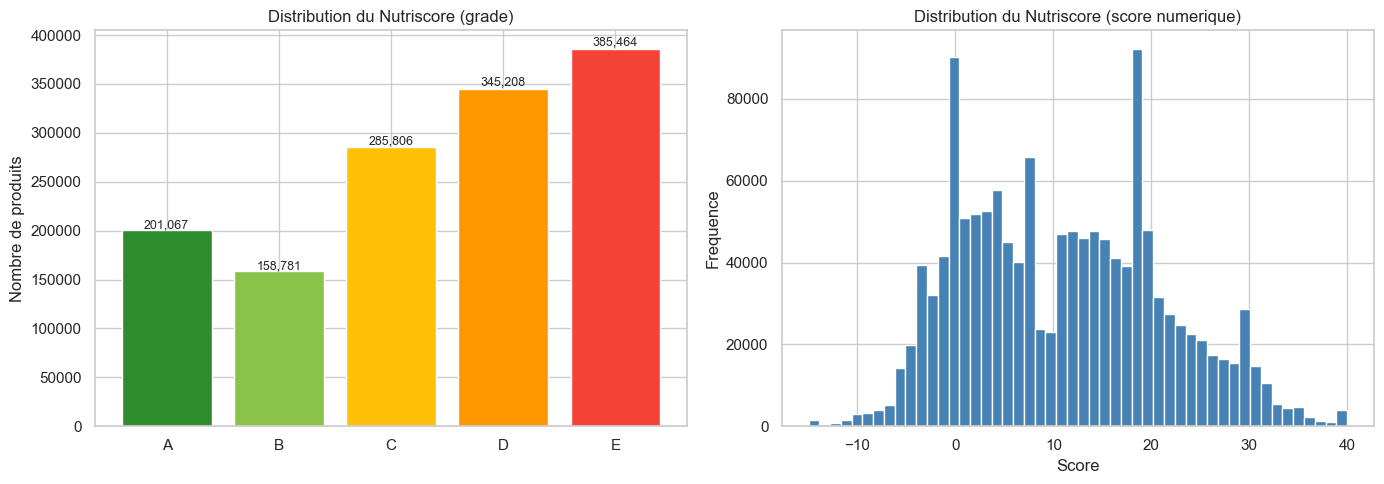

Produits avec nutriscore renseigne : 4,490,851 (99.0%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nutriscore_order = ['a', 'b', 'c', 'd', 'e']
nutriscore_colors = ['#2d8c2d', '#8bc34a', '#ffc107', '#ff9800', '#f44336']

counts = df_focus['nutriscore_grade'].value_counts()
counts_ordered = counts.reindex(nutriscore_order).dropna()

axes[0].bar(counts_ordered.index.str.upper(), counts_ordered.values, color=nutriscore_colors[:len(counts_ordered)])
axes[0].set_title('Distribution du Nutriscore (grade)')
axes[0].set_ylabel('Nombre de produits')
for i, v in enumerate(counts_ordered.values):
    axes[0].text(i, v + v*0.01, f'{v:,}', ha='center', fontsize=9)

df_focus['nutriscore_score'].dropna().clip(-15, 40).hist(bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribution du Nutriscore (score numerique)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequence')

plt.tight_layout()
plt.show()

print(f"Produits avec nutriscore renseigne : {df_focus['nutriscore_grade'].notna().sum():,} ({df_focus['nutriscore_grade'].notna().mean():.1%})")

## 7. Distribution du groupe NOVA (niveau de transformation)

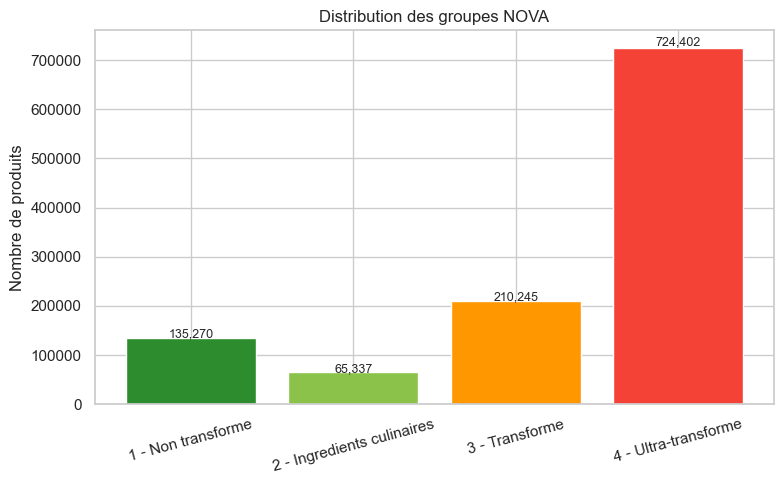

Produits avec NOVA renseigne : 1,135,254 (25.0%)


In [9]:
nova_labels = {1: '1 - Non transforme', 2: '2 - Ingredients culinaires', 3: '3 - Transforme', 4: '4 - Ultra-transforme'}
nova_colors = ['#2d8c2d', '#8bc34a', '#ff9800', '#f44336']

nova_counts = df_focus['nova_group'].value_counts().sort_index()
nova_counts = nova_counts[nova_counts.index.isin([1, 2, 3, 4])]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([nova_labels.get(i, str(i)) for i in nova_counts.index], nova_counts.values, color=nova_colors)
ax.set_title('Distribution des groupes NOVA')
ax.set_ylabel('Nombre de produits')
for bar, v in zip(bars, nova_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + v*0.01, f'{v:,}', ha='center', fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Produits avec NOVA renseigne : {df_focus['nova_group'].notna().sum():,} ({df_focus['nova_group'].notna().mean():.1%})")

## 8. Distribution des macronutriments

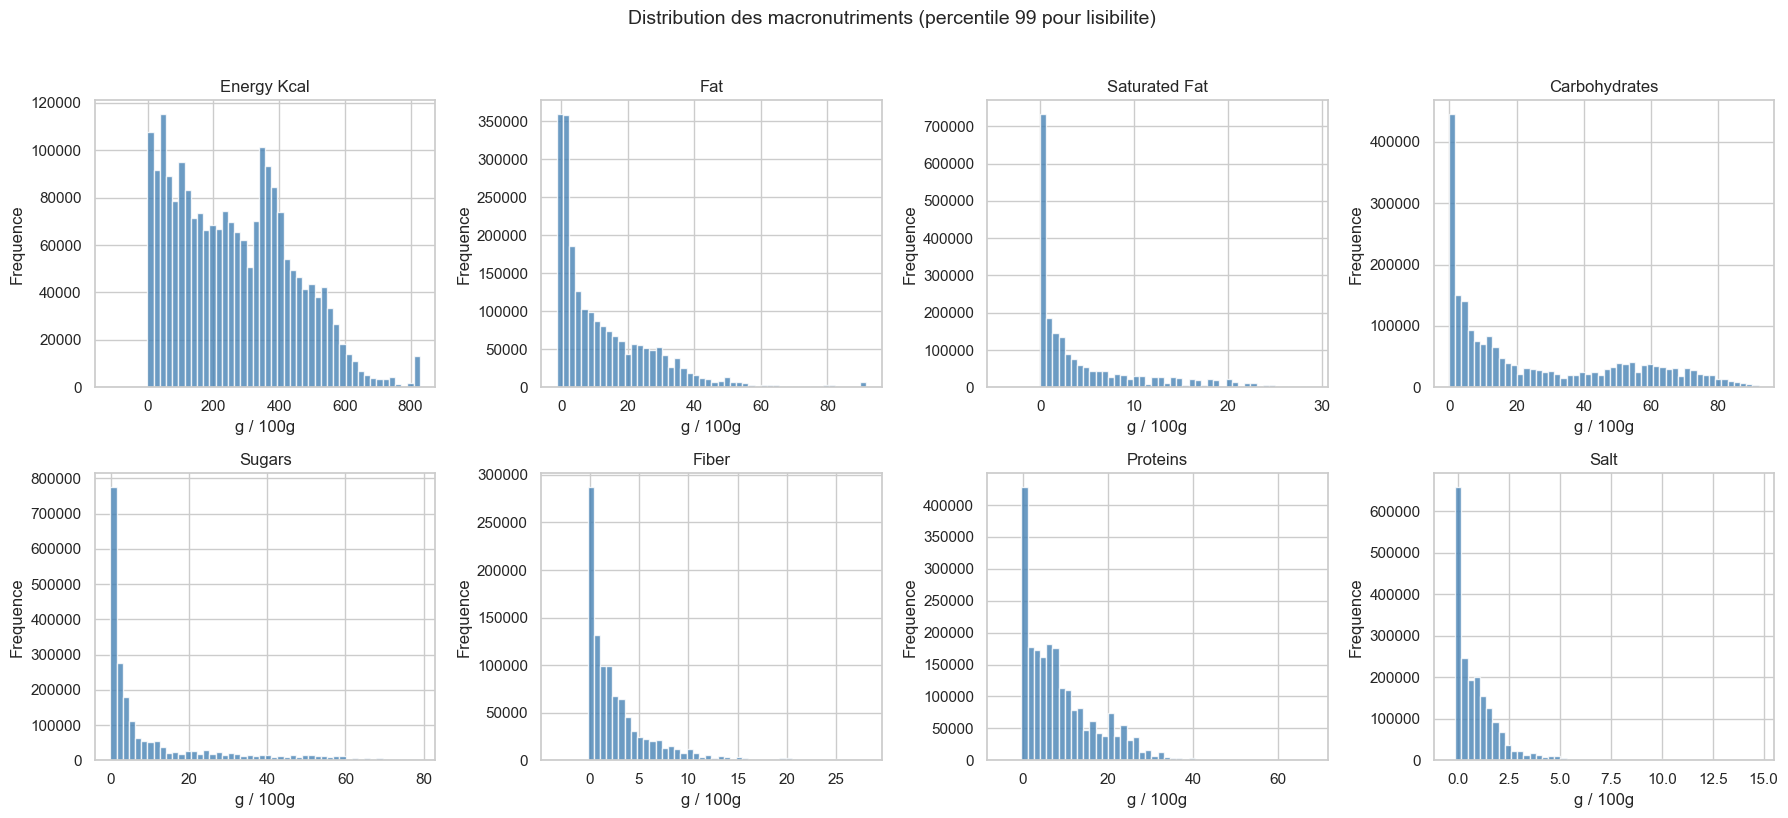

In [10]:
macros = ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g',
          'sugars_100g', 'fiber_100g', 'proteins_100g', 'salt_100g']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(macros):
    data = df_focus[col].dropna()
    q99 = data.quantile(0.99)
    data_clipped = data[data <= q99]
    axes[i].hist(data_clipped, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_100g', '').replace('-', ' ').title())
    axes[i].set_xlabel('g / 100g')
    axes[i].set_ylabel('Frequence')

plt.suptitle('Distribution des macronutriments (percentile 99 pour lisibilite)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
df_focus[macros].describe().T

,count,mean,std,min,25%,50%,75%,max
energy-kcal_100g,2236278.0,6.364458e+09,9.517531e+12,-113.860000,109.0000,253.000000,394.000000,1.423270e+16
fat_100g,2212539.0,2.178415e+01,1.180157e+04,-1.433973,1.1600,7.300000,21.000000,1.755400e+07
saturated-fat_100g,2129368.0,5.468746e+00,4.047104e+02,-3.992188,0.2000,1.904762,7.000000,5.880000e+05
carbohydrates_100g,2213045.0,3.324927e+01,9.733639e+03,-0.114780,3.0000,14.000000,50.000000,1.447977e+07
sugars_100g,2145539.0,5.475162e+26,8.019831e+29,-0.087300,0.6000,3.200000,14.322403,1.174717e+33
fiber_100g,1033315.0,5.914224e+06,6.011919e+09,-3.333333,0.1380,1.666667,3.900000,6.111242e+12
proteins_100g,2216225.0,1.755262e+03,1.829753e+06,-4.761905,2.0000,6.700000,14.000000,2.522222e+09
salt_100g,1953078.0,1.145868e+02,1.570784e+05,-0.454363,0.0975,0.570000,1.400000,2.195208e+08


## 9. Matrice de correlation des nutriments

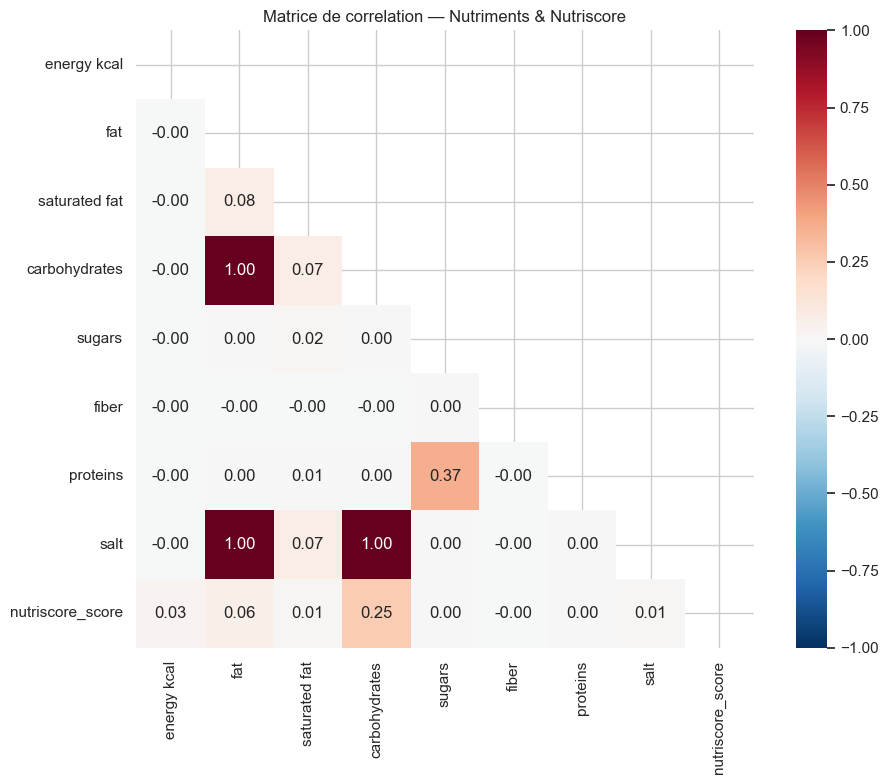

In [12]:
corr_cols = macros + ['nutriscore_score']
corr_matrix = df_focus[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            xticklabels=[c.replace('_100g', '').replace('-', ' ') for c in corr_cols],
            yticklabels=[c.replace('_100g', '').replace('-', ' ') for c in corr_cols])
ax.set_title('Matrice de correlation — Nutriments & Nutriscore')
plt.tight_layout()
plt.show()

## 10. Analyse des categories de produits

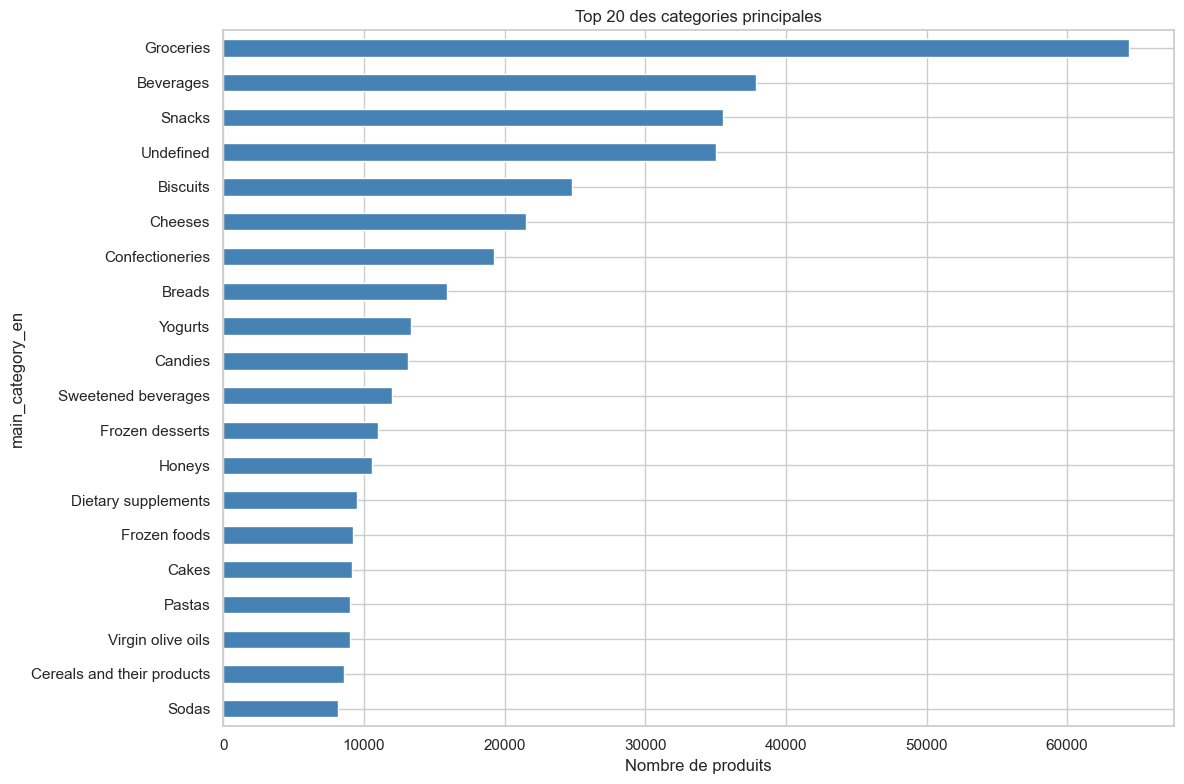

Nombre de categories distinctes (main_category_en) : 80,172


In [13]:
top_categories = df_focus['main_category_en'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top_categories.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Nombre de produits')
ax.set_title('Top 20 des categories principales')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Nombre de categories distinctes (main_category_en) : {df_focus['main_category_en'].nunique():,}")

## 11. Nutriscore moyen par categorie

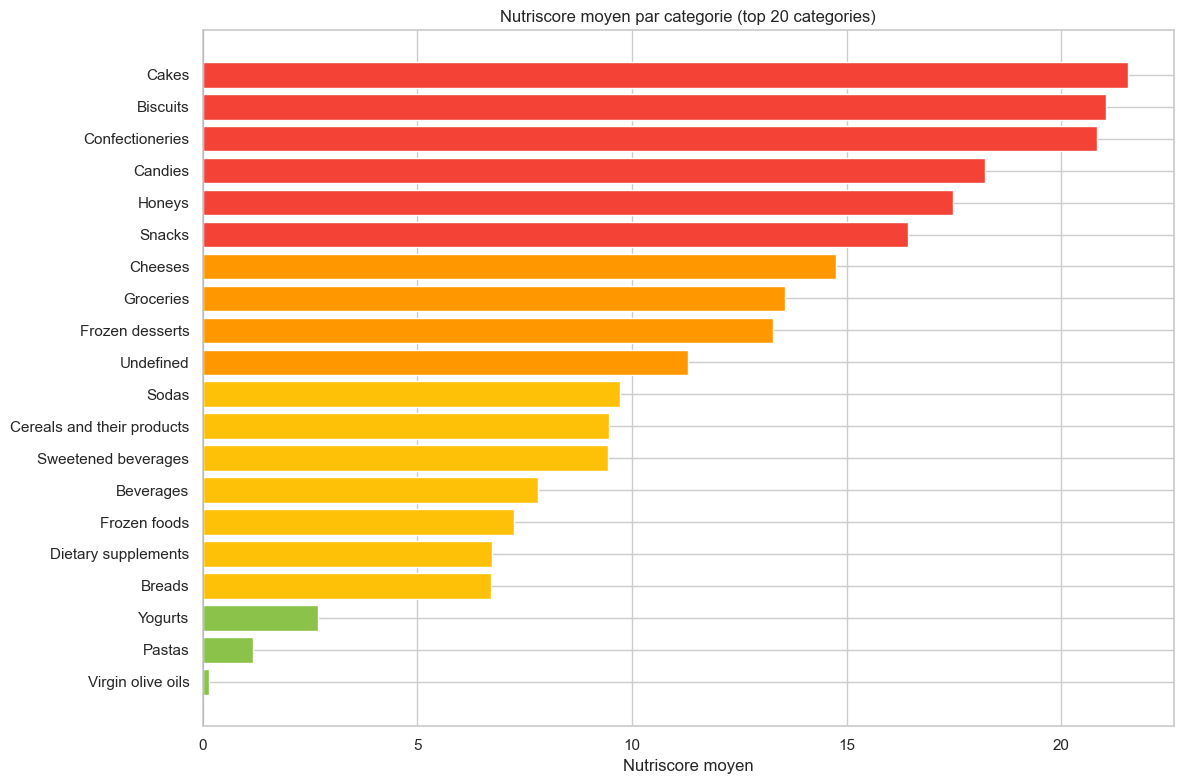

In [14]:
top_20_cats = df_focus['main_category_en'].value_counts().head(20).index

cat_nutriscore = (df_focus[df_focus['main_category_en'].isin(top_20_cats)]
                  .groupby('main_category_en')['nutriscore_score']
                  .agg(['mean', 'median', 'count'])
                  .sort_values('mean'))

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2d8c2d' if v < 0 else '#8bc34a' if v < 5 else '#ffc107' if v < 10 else '#ff9800' if v < 15 else '#f44336'
          for v in cat_nutriscore['mean']]
ax.barh(cat_nutriscore.index, cat_nutriscore['mean'], color=colors)
ax.set_xlabel('Nutriscore moyen')
ax.set_title('Nutriscore moyen par categorie (top 20 categories)')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 12. Analyse des labels et regimes alimentaires

Explorer les labels existants (bio, vegan, sans gluten...) pour comprendre quelles informations de regime sont deja disponibles.

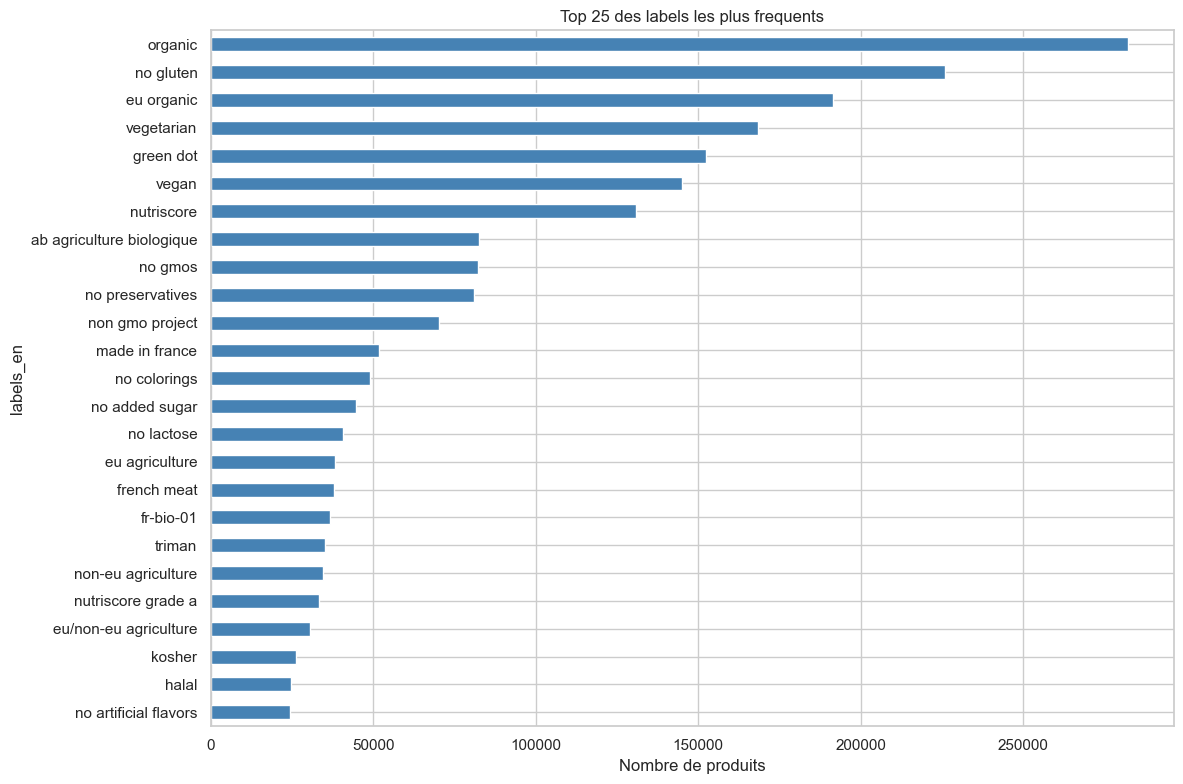

In [15]:
labels_series = df_focus['labels_en'].dropna().str.split(',').explode().str.strip().str.lower()
top_labels = labels_series.value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))
top_labels.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Nombre de produits')
ax.set_title('Top 25 des labels les plus frequents')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Analyse des ingredients (tags d'analyse)

In [16]:
analysis_tags = df_focus['ingredients_analysis_tags'].dropna().str.split(',').explode().str.strip()
tag_counts = analysis_tags.value_counts()

print("Tags d'analyse des ingredients :")
print(tag_counts.to_string())
print(f"\nProduits avec analyse des ingredients : {df_focus['ingredients_analysis_tags'].notna().sum():,}")

Tags d'analyse des ingredients :
ingredients_analysis_tags
en:palm-oil-free                779708
en:vegetarian-status-unknown    654604
en:non-vegan                    540309
en:vegan-status-unknown         433913
en:vegetarian                   395366
en:vegan                        303076
en:palm-oil-content-unknown     290192
en:non-vegetarian               188902
en:maybe-vegetarian             124595
en:palm-oil                     110403
en:may-contain-palm-oil         104202
en:maybe-vegan                   80880

Produits avec analyse des ingredients : 1,363,472


## 14. Analyse des allergenes

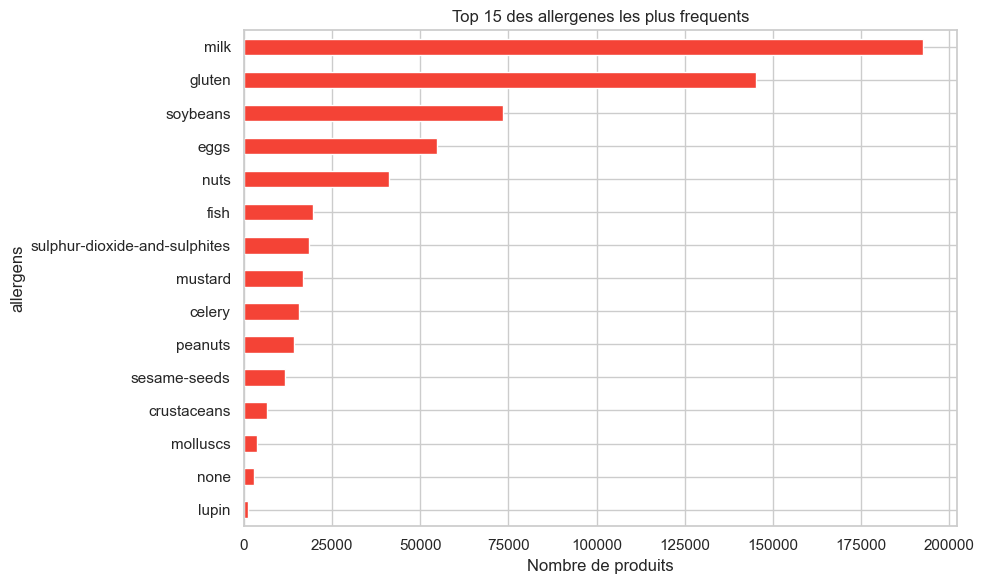

Produits avec allergenes renseignes : 367,684 (8.1%)


In [17]:
allergens_series = (df_focus['allergens'].dropna()
                    .str.split(',')
                    .explode()
                    .str.strip()
                    .str.replace(r'^[a-z]{2}:', '', regex=True)
                    .str.lower())
allergens_series = allergens_series[allergens_series != '']
top_allergens = allergens_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_allergens.plot(kind='barh', ax=ax, color='#f44336')
ax.set_xlabel('Nombre de produits')
ax.set_title('Top 15 des allergenes les plus frequents')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Produits avec allergenes renseignes : {df_focus['allergens'].notna().sum():,} ({df_focus['allergens'].notna().mean():.1%})")

## 15. Detection d'anomalies dans les valeurs nutritionnelles

Identifier les valeurs aberrantes (ex: plus de 100g de proteines pour 100g de produit).

In [18]:
anomalies = {}
nutrient_max = {
    'fat_100g': 100, 'saturated-fat_100g': 100,
    'carbohydrates_100g': 100, 'sugars_100g': 100,
    'proteins_100g': 100, 'salt_100g': 100,
    'fiber_100g': 100, 'energy-kcal_100g': 900
}

print("Valeurs aberrantes detectees :")
print("-" * 50)
for col, max_val in nutrient_max.items():
    n_above = (df_focus[col] > max_val).sum()
    n_negative = (df_focus[col] < 0).sum()
    anomalies[col] = {'> max': n_above, '< 0': n_negative}
    if n_above > 0 or n_negative > 0:
        print(f"{col:30s} | > {max_val}: {n_above:>8,} | < 0: {n_negative:>8,}")

print(f"\n--- Somme des macros (fat + carbs + proteins + fiber) > 100g ---")
macro_sum = df_focus[['fat_100g', 'carbohydrates_100g', 'proteins_100g', 'fiber_100g']].sum(axis=1)
n_impossible = (macro_sum > 105).sum()
print(f"Produits avec somme > 105g : {n_impossible:,}")

Valeurs aberrantes detectees :
--------------------------------------------------
fat_100g                       | > 100:      404 | < 0:        2
saturated-fat_100g             | > 100:      162 | < 0:        4
carbohydrates_100g             | > 100:      810 | < 0:        1
sugars_100g                    | > 100:      308 | < 0:        1
proteins_100g                  | > 100:      287 | < 0:        3
salt_100g                      | > 100:    1,038 | < 0:        4
fiber_100g                     | > 100:      115 | < 0:      161
energy-kcal_100g               | > 900:    3,934 | < 0:        1

--- Somme des macros (fat + carbs + proteins + fiber) > 100g ---
Produits avec somme > 105g : 14,662


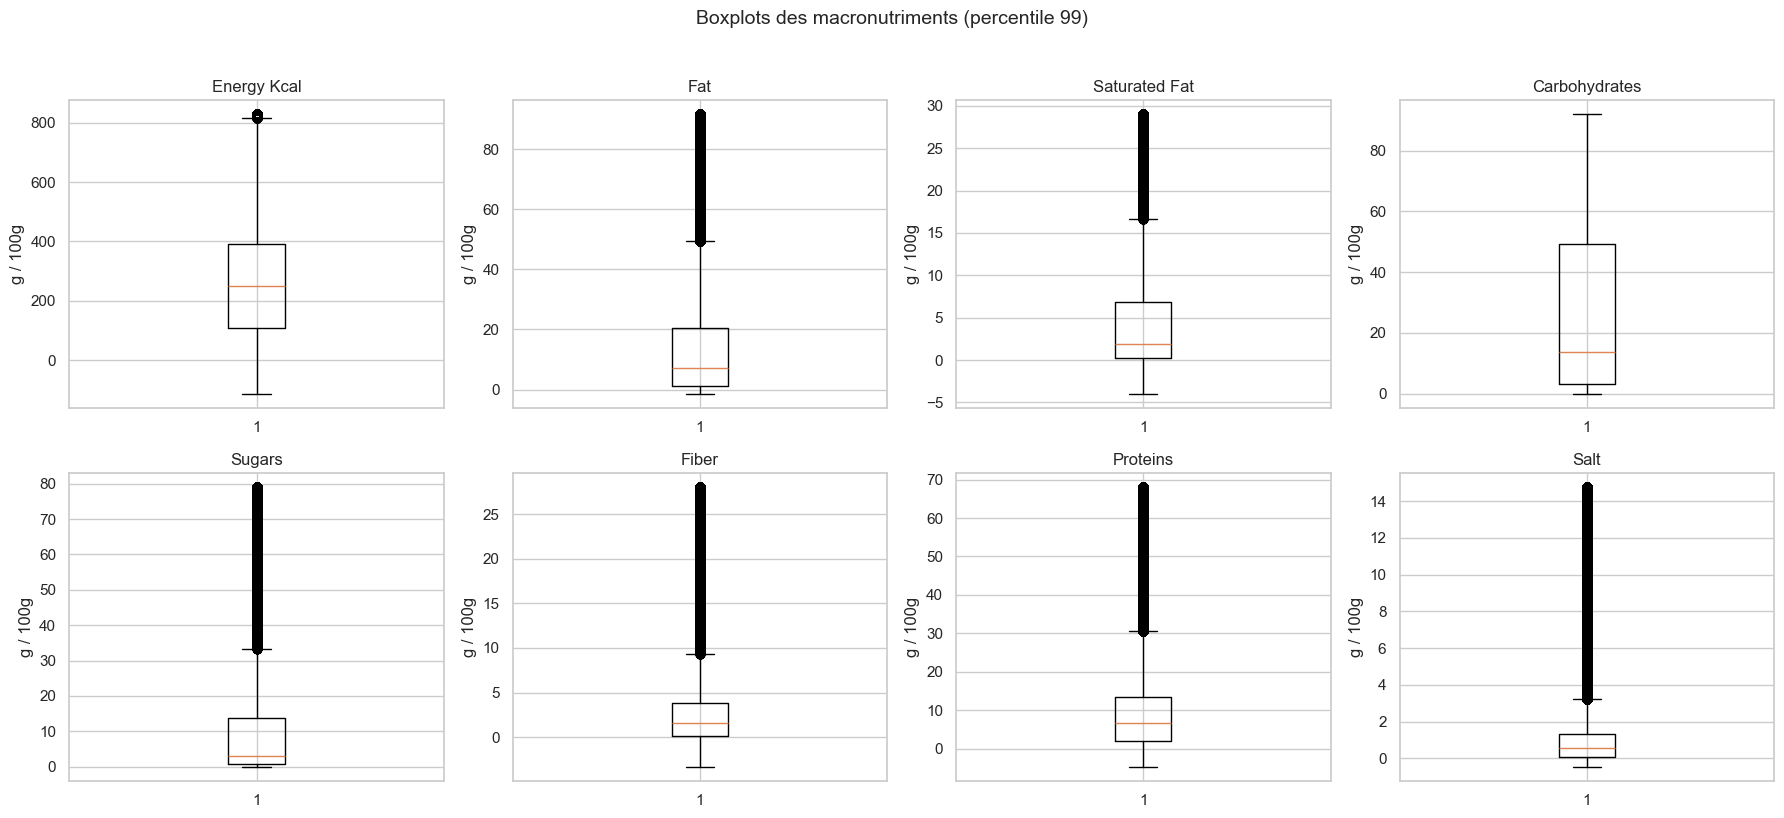

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(macros):
    data = df_focus[col].dropna()
    axes[i].boxplot(data[data <= data.quantile(0.99)], vert=True)
    axes[i].set_title(col.replace('_100g', '').replace('-', ' ').title())
    axes[i].set_ylabel('g / 100g')

plt.suptitle('Boxplots des macronutriments (percentile 99)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 16. Completude des donnees (score de qualite)

Le champ `completeness` d'Open Food Facts indique le taux de remplissage de chaque fiche produit.

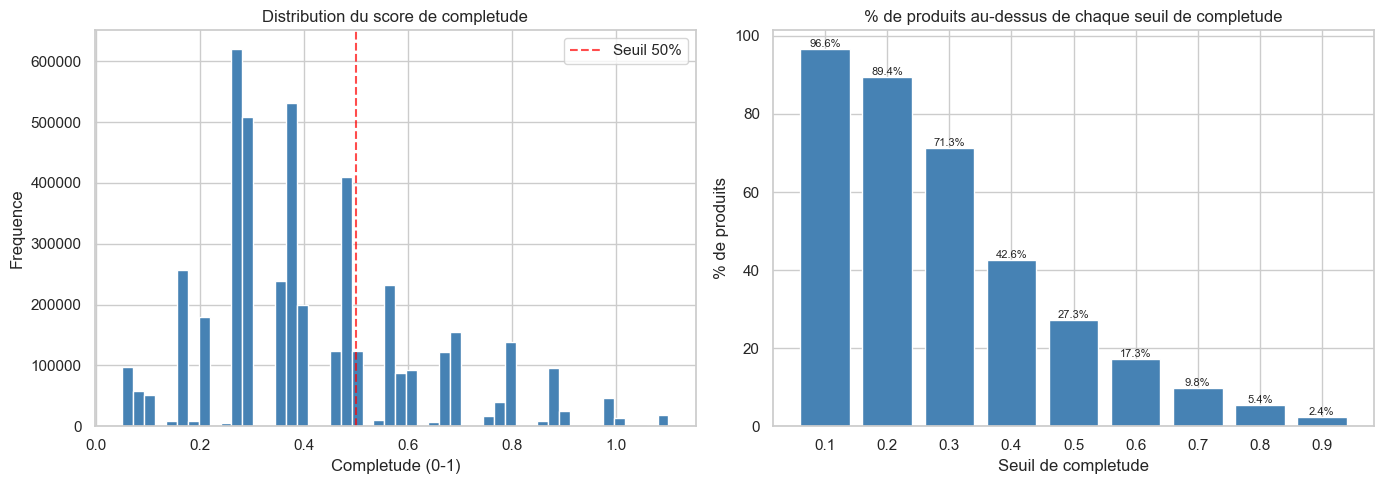

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_focus['completeness'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du score de completude')
axes[0].set_xlabel('Completude (0-1)')
axes[0].set_ylabel('Frequence')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Seuil 50%')
axes[0].legend()

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
pct_above = [((df_focus['completeness'] >= t).sum() / len(df_focus)) * 100 for t in thresholds]
axes[1].bar([str(t) for t in thresholds], pct_above, color='steelblue')
axes[1].set_title('% de produits au-dessus de chaque seuil de completude')
axes[1].set_xlabel('Seuil de completude')
axes[1].set_ylabel('% de produits')
for i, v in enumerate(pct_above):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 17. Repartition geographique des produits

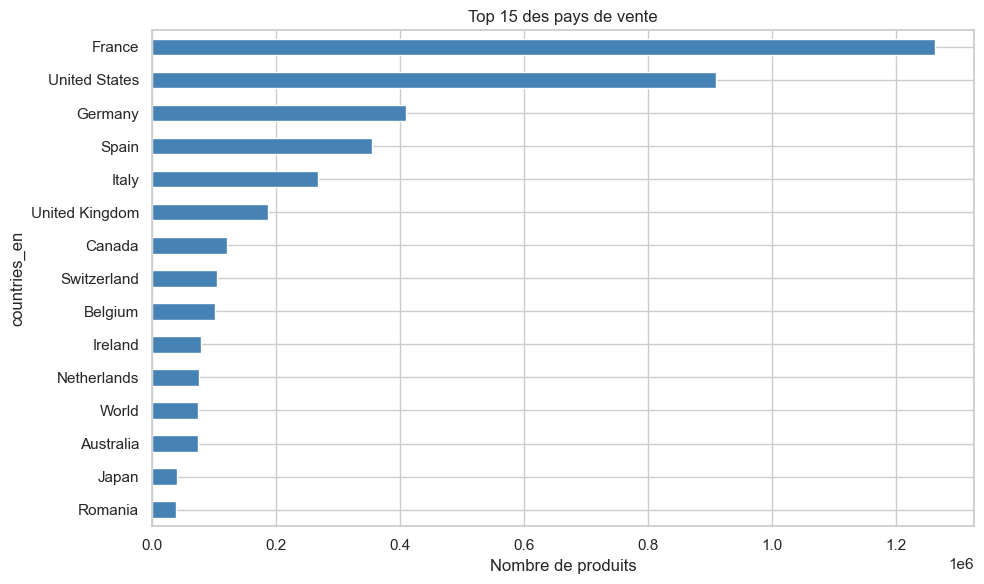

In [21]:
countries = df_focus['countries_en'].dropna().str.split(',').explode().str.strip()
top_countries = countries.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_countries.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Nombre de produits')
ax.set_title('Top 15 des pays de vente')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 18. Nombre d'additifs par produit

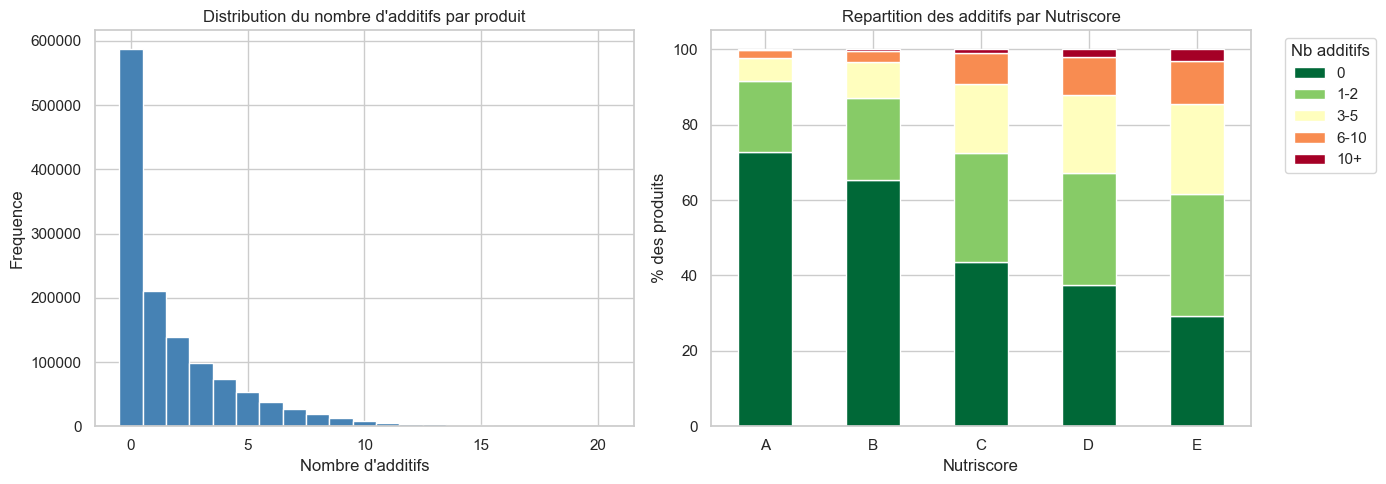

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

additives = df_focus['additives_n'].dropna()
additives_clipped = additives[additives <= 20]
axes[0].hist(additives_clipped, bins=range(0, 22), color='steelblue', edgecolor='white', align='left')
axes[0].set_title("Distribution du nombre d'additifs par produit")
axes[0].set_xlabel("Nombre d'additifs")
axes[0].set_ylabel('Frequence')

cross = pd.crosstab(
    df_focus['nutriscore_grade'],
    pd.cut(df_focus['additives_n'], bins=[-1, 0, 2, 5, 10, 100],
           labels=['0', '1-2', '3-5', '6-10', '10+'])
)
cross = cross.reindex(nutriscore_order)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='RdYlGn_r')
axes[1].set_title("Repartition des additifs par Nutriscore")
axes[1].set_xlabel('Nutriscore')
axes[1].set_ylabel('% des produits')
axes[1].legend(title="Nb additifs", bbox_to_anchor=(1.05, 1))
axes[1].set_xticklabels([g.upper() for g in nutriscore_order], rotation=0)

plt.tight_layout()
plt.show()

## 19. Profil nutritionnel par Nutriscore

Comparer les profils nutritionnels moyens selon le grade Nutriscore.

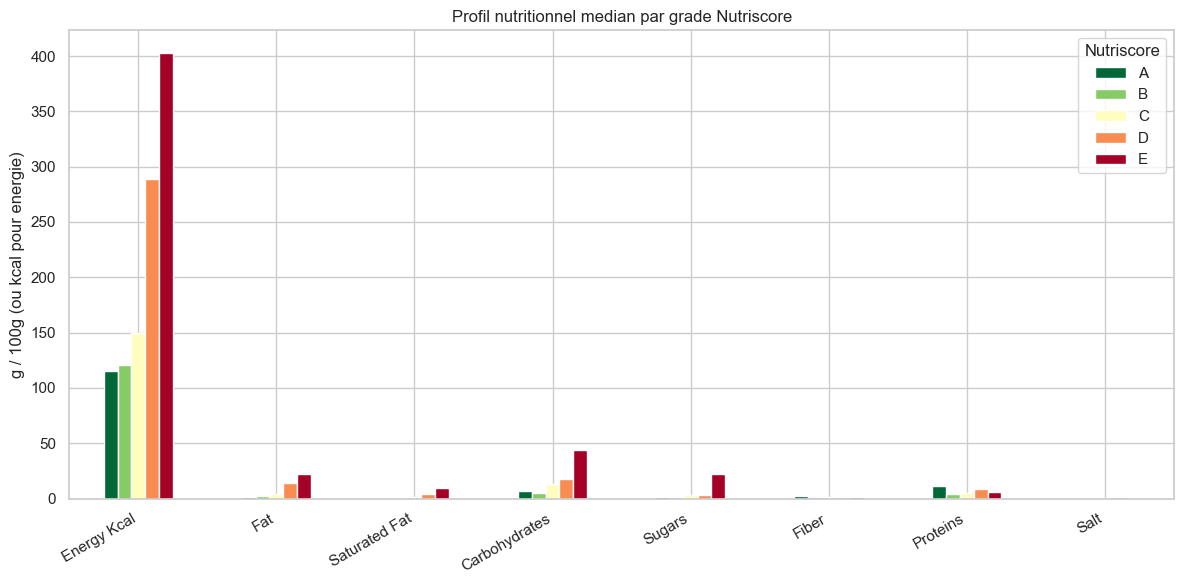

In [23]:
profile = (df_focus[df_focus['nutriscore_grade'].isin(nutriscore_order)]
           .groupby('nutriscore_grade')[macros]
           .median()
           .reindex(nutriscore_order))

profile.columns = [c.replace('_100g', '').replace('-', ' ').title() for c in profile.columns]

fig, ax = plt.subplots(figsize=(12, 6))
profile.T.plot(kind='bar', ax=ax, colormap='RdYlGn_r')
ax.set_title('Profil nutritionnel median par grade Nutriscore')
ax.set_ylabel('g / 100g (ou kcal pour energie)')
ax.set_xlabel('')
ax.legend(title='Nutriscore', labels=[g.upper() for g in nutriscore_order])
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 20. Synthese et conclusions de l'EDA

### Observations cles

**Volume et qualite :**
- 4.5M+ produits, mais beaucoup de colonnes tres creuses (>90% de valeurs manquantes pour les micronutriments rares)
- Le score de completude permet de filtrer les produits exploitables
- Des valeurs aberrantes sont presentes (valeurs negatives, depassement de 100g/100g) — a nettoyer dans le pipeline ETL

**Pour le systeme de recommandation :**
- Les colonnes cles (macronutriments, nutriscore, nova, categories, labels, allergenes) sont suffisamment remplies
- Les labels existants (bio, vegan, sans gluten...) fournissent une base pour le filtrage par regime
- Les `ingredients_analysis_tags` permettent de detecter les produits vegan/vegetariens/avec huile de palme
- La correlation entre nutriments et nutriscore est forte — utile pour la classification

### Prochaines etapes
1. **Pipeline ETL** : nettoyage des anomalies, selection des colonnes, traitement des valeurs manquantes
2. **Choix de la BDD** : a decider selon le volume final apres nettoyage
3. **Feature engineering** : creer des flags par regime (is_vegan, is_keto, is_gluten_free, etc.)
4. **Modelisation** : classification supervisee + clustering pour recommandation